# 1. Load Data

In [2]:
# Global Import and Directories
import sys
sys.path.append("..")
import Setup
from Setup import *

Current working directory: /home/qusta100/STGNN/02_Notebooks/02_Summary_Statistics


In [4]:
# Load data (restore from saved file)
df = pd.read_csv(
    Setup.DATA_SCRATCH / "02_Processed_Data" / "02_Analysis" / "final_df.csv",
    dtype={9: str}
)

/var/tmp/pbs.16951945.hpc-batch/ipykernel_36557/842838095.py:2: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/gpfs/scratch/qusta100/STGNN/01_Data/02_Processed_Data/02_Analysis/final_df.csv")


In [14]:
df.head()

,date,station_uuid,diesel,e5,e10,uuid,name,brand,street,house_number,...,t_87,t_88,t_89,t_90,t_91,t_92,t_93,t_94,t_95,weekday
0,2025-04-01 00:00:00,00060065-7890-4444-8888-acdc00000004,1.559,1.709,1.649,00060065-7890-4444-8888-acdc00000004,Georg Ultsch GmbH,Tankstelle Lichtenfels,Robert-Koch-Str.,18.0,...,False,False,False,False,False,False,False,False,False,1
1,2025-04-01 00:15:00,00060065-7890-4444-8888-acdc00000004,1.559,1.709,1.649,00060065-7890-4444-8888-acdc00000004,Georg Ultsch GmbH,Tankstelle Lichtenfels,Robert-Koch-Str.,18.0,...,False,False,False,False,False,False,False,False,False,1
2,2025-04-01 00:30:00,00060065-7890-4444-8888-acdc00000004,1.559,1.709,1.649,00060065-7890-4444-8888-acdc00000004,Georg Ultsch GmbH,Tankstelle Lichtenfels,Robert-Koch-Str.,18.0,...,False,False,False,False,False,False,False,False,False,1
3,2025-04-01 00:45:00,00060065-7890-4444-8888-acdc00000004,1.559,1.709,1.649,00060065-7890-4444-8888-acdc00000004,Georg Ultsch GmbH,Tankstelle Lichtenfels,Robert-Koch-Str.,18.0,...,False,False,False,False,False,False,False,False,False,1
4,2025-04-01 01:00:00,00060065-7890-4444-8888-acdc00000004,1.559,1.709,1.649,00060065-7890-4444-8888-acdc00000004,Georg Ultsch GmbH,Tankstelle Lichtenfels,Robert-Koch-Str.,18.0,...,False,False,False,False,False,False,False,False,False,1


In [4]:
# List all variables (columns)
print(df.columns.tolist())

# Print total number of observations (rows)
print(len(df))

# Print number of unique station_uuid values
print(df['station_uuid'].nunique())

['date', 'station_uuid', 'diesel', 'e5', 'e10', 'uuid', 'name', 'brand', 'street', 'house_number', 'post_code', 'city', 'latitude', 'longitude', 'first_active', 'openingtimes_json', 'in_thuringia', 'in_region', 'last_seen', 'is_open', 'holiday', 'time_sin', 'time_cos', 'brand_cat', 'Brent_Price', 'wd_0', 'wd_1', 'wd_2', 'wd_3', 'wd_4', 'wd_5', 'wd_6', 't_0', 't_1', 't_2', 't_3', 't_4', 't_5', 't_6', 't_7', 't_8', 't_9', 't_10', 't_11', 't_12', 't_13', 't_14', 't_15', 't_16', 't_17', 't_18', 't_19', 't_20', 't_21', 't_22', 't_23', 't_24', 't_25', 't_26', 't_27', 't_28', 't_29', 't_30', 't_31', 't_32', 't_33', 't_34', 't_35', 't_36', 't_37', 't_38', 't_39', 't_40', 't_41', 't_42', 't_43', 't_44', 't_45', 't_46', 't_47', 't_48', 't_49', 't_50', 't_51', 't_52', 't_53', 't_54', 't_55', 't_56', 't_57', 't_58', 't_59', 't_60', 't_61', 't_62', 't_63', 't_64', 't_65', 't_66', 't_67', 't_68', 't_69', 't_70', 't_71', 't_72', 't_73', 't_74', 't_75', 't_76', 't_77', 't_78', 't_79', 't_80', 't_81', 

# 2. Graphs

## 2.1. Average Fuel Price per Category

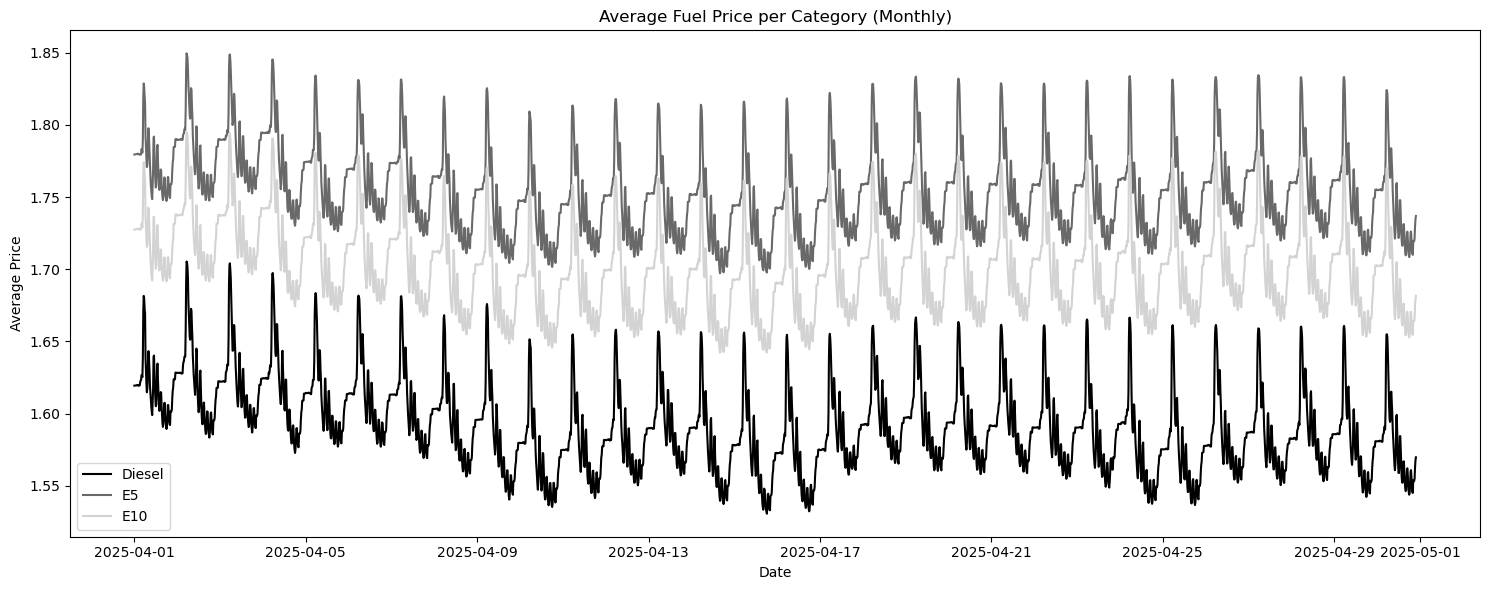

In [36]:
# Convert 'date' column to datetime if not already done
df['date'] = pd.to_datetime(df['date'])

# Group by timestamp and calculate mean prices
avg_prices = df.groupby('date')[['diesel', 'e5', 'e10']].mean()

# Create plot
plt.figure(figsize=(15, 6))
plt.plot(avg_prices.index, avg_prices['diesel'], label='Diesel', color='black')
plt.plot(avg_prices.index, avg_prices['e5'], label='E5', color='dimgray')
plt.plot(avg_prices.index, avg_prices['e10'], label='E10', color='lightgray')

plt.xlabel('Date')
plt.ylabel('Average Price')
plt.title('Average Fuel Price per Category (Monthly)')
plt.legend()
plt.tight_layout()
plt.savefig(
    Setup.GRAPHS_DIR / "01_Descriptive_Statistics" / "02_01_price_month.png",
    dpi=200
)
plt.show()

## 2.2 Average Fuel Prices by Category

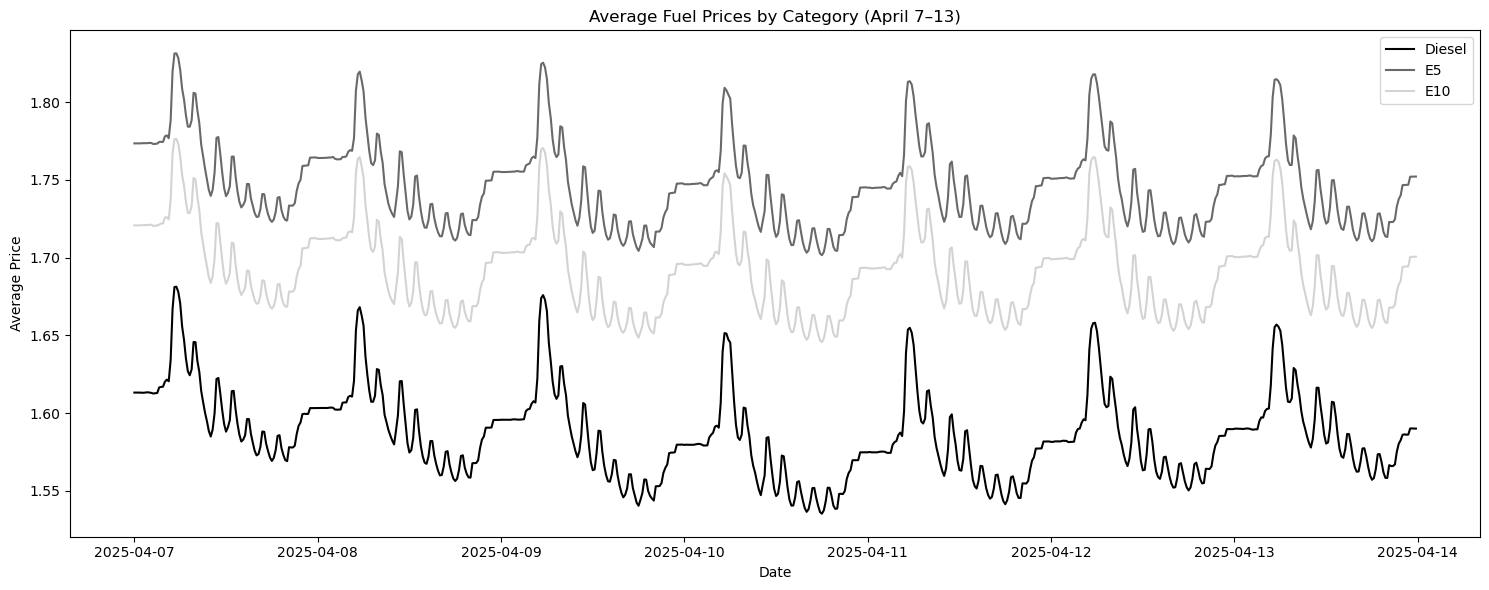

In [49]:
# Convert 'date' column to datetime
df['date'] = pd.to_datetime(df['date'])

# Select time range: April 7 to April 13
start = pd.Timestamp('2025-04-07')
end = pd.Timestamp('2025-04-13 23:59:59')
mask = (df['date'] >= start) & (df['date'] <= end)
subset = df.loc[mask]

# Group by timestamp and calculate mean prices
avg_prices = subset.groupby('date')[['diesel', 'e5', 'e10']].mean()

# Plot
plt.figure(figsize=(15, 6))
plt.plot(avg_prices.index, avg_prices['diesel'], label='Diesel', color='black')
plt.plot(avg_prices.index, avg_prices['e5'], label='E5', color='dimgray')
plt.plot(avg_prices.index, avg_prices['e10'], label='E10', color='lightgray')
plt.xlabel('Date')
plt.ylabel('Average Price')
plt.title('Average Fuel Prices by Category (April 7–13)')
plt.legend()
plt.tight_layout()
plt.savefig(
    Setup.GRAPHS_DIR / "01_Descriptive_Statistics" / "02_02_price_week.png",
    dpi=200
)
plt.show()

## 2.3 Number of Price Changes

In [39]:
# 1) Date format and sorting
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values(['station_uuid', 'date'])

# 2) Calendar day
df['day'] = df['date'].dt.floor('D')

# 3) Mark Price Change per Station (True wenn Price_t != Price_t-1)
cols = ['e5', 'e10', 'diesel']

group = df.groupby('station_uuid')[cols]
shifted = group.shift()

for c in cols:
    df[f'price_changed_{c}'] = df[c].ne(shifted[c]) & df[c].notna()

# 4) Count per station and day
results = []

for f in cols:
    tmp = (
        df.groupby(['station_uuid', 'day'])[f'price_changed_{f}']
          .sum()
          .astype(int)
          .rename(f'num_price_changes_{f}')
          .reset_index()
    )
    results.append(tmp)
    
changes_per_day = results[0]
for r in results[1:]:
    changes_per_day = changes_per_day.merge(r, on=['station_uuid', 'day'])

# 5) Computation of Statistics
stats = {}
for f in cols:
    col = f'num_price_changes_{f}'
    stats[f] = {
        'avg': changes_per_day[col].mean(),
        'min': changes_per_day[col].min(),
        'max': changes_per_day[col].max()
    }

# 6) Output of Statistics
for f, v in stats.items():
    print(f"{f}: avg={v['avg']:.2f}, min={v['min']}, max={v['max']}")

e5: avg=18.57, min=0, max=47
e10: avg=17.43, min=0, max=47
diesel: avg=19.39, min=0, max=48


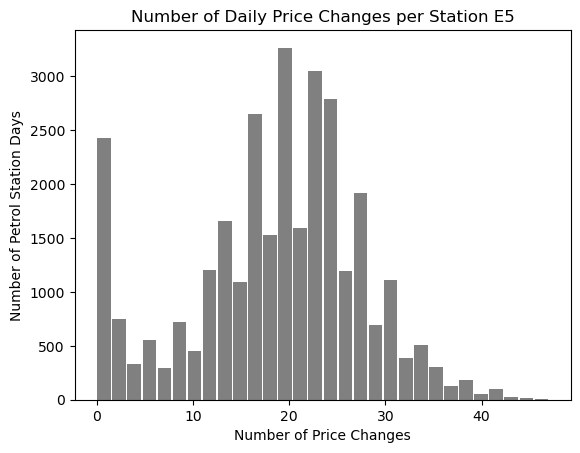

In [40]:
# Number of Price Changes, E5
plt.figure()
plt.hist(
    changes_per_day['num_price_changes_e5'],
    bins=30,
    density=False,
    color='gray',
    rwidth=0.9 
)
plt.title("Number of Daily Price Changes per Station E5")
plt.xlabel("Number of Price Changes")
plt.ylabel("Number of Petrol Station Days")
plt.savefig(
    Setup.GRAPHS_DIR / "01_Descriptive_Statistics" / "02_03_price_changes_E5.png",
    dpi=200
)
plt.show()

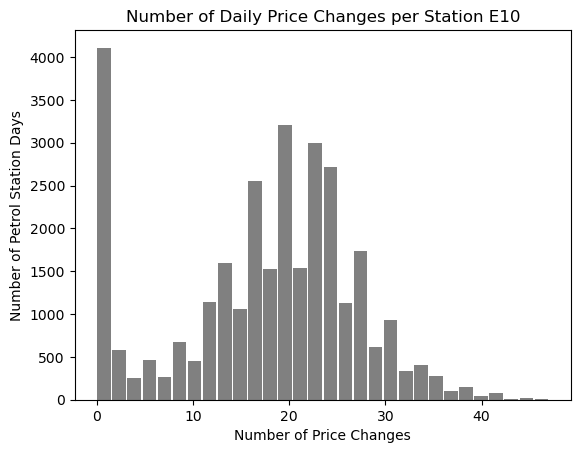

In [41]:
# Number of Price Changes, E10
plt.figure()
plt.hist(
    changes_per_day['num_price_changes_e10'],
    bins=30,
    density=False,
    color='gray',
    rwidth=0.9 
)
plt.title("Number of Daily Price Changes per Station E10")
plt.xlabel("Number of Price Changes")
plt.ylabel("Number of Petrol Station Days")
plt.savefig(
    Setup.GRAPHS_DIR / "01_Descriptive_Statistics" / "02_04_price_changes_E10.png",
    dpi=200
)
plt.show()

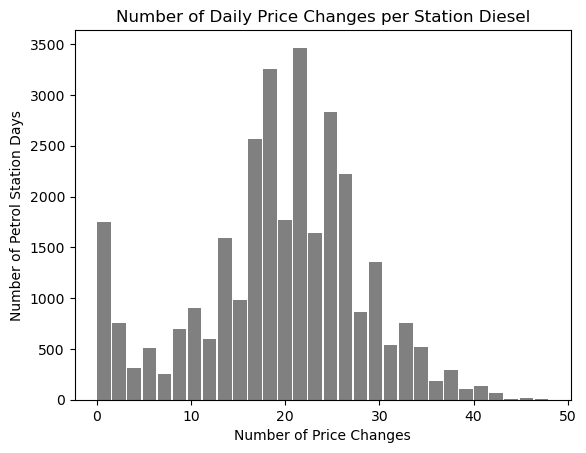

In [42]:
# Number of Price Changes, Diesel
plt.figure()
plt.hist(
    changes_per_day['num_price_changes_diesel'],
    bins=30,
    density=False,
    color='gray',
    rwidth=0.9 
)
plt.title("Number of Daily Price Changes per Station Diesel")
plt.xlabel("Number of Price Changes")
plt.ylabel("Number of Petrol Station Days")
plt.savefig(
    Setup.GRAPHS_DIR / "01_Descriptive_Statistics" / "02_05_price_changes_Diesel.png",
    dpi=200
)
plt.show()

## 2.4 Time interval between price changes

In [44]:
# make sure date is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

def compute_changes(df, flag):
    tmp = df[df[flag]]
    return (
        tmp.assign(time_since_last_change =
                   tmp.groupby('station_uuid')['date'].diff())
           .dropna(subset=['time_since_last_change'])
    )

changes_e5 = compute_changes(df, 'price_changed_e5')
changes_e10 = compute_changes(df, 'price_changed_e10')
changes_diesel = compute_changes(df, 'price_changed_diesel')

In [45]:
def add_stats(df, name):
    df['minutes_since_change'] = df['time_since_last_change'].dt.total_seconds() / 60
    avg_time = df['minutes_since_change'].mean()
    min_time = df['minutes_since_change'].min()
    max_time = df['minutes_since_change'].max()
    print(f"{name}: Avg {avg_time:.2f}, Min {min_time:.2f}, Max {max_time:.2f}")

add_stats(changes_e5, "E5")
add_stats(changes_e10, "E10")
add_stats(changes_diesel, "Diesel")

E5: Avg 74.03, Min 15.00, Max 29160.00
E10: Avg 73.80, Min 15.00, Max 29160.00
Diesel: Avg 72.81, Min 15.00, Max 39615.00


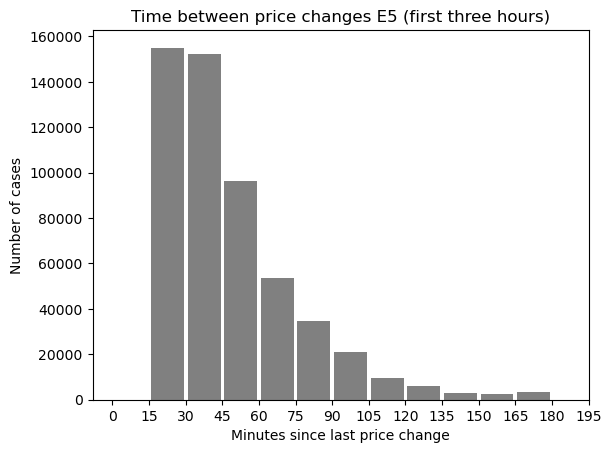

In [46]:
# Time interval between price changes, E5
mask = changes_e5['minutes_since_change'] <= 180

plt.figure()
plt.hist(
    changes_e5.loc[mask, 'minutes_since_change'],
    bins = np.arange(0, 195, 15),
    density=False,
    color='gray',
    rwidth=0.9 
)
plt.title("Time between price changes E5 (first three hours)")
plt.xlabel("Minutes since last price change")
plt.ylabel("Number of cases")
xticks = range(0, 201, 15)
plt.xticks(xticks)
plt.savefig("/home/qusta100/STGNN/03_Graphs/01_Descriptive_Statistics/02_06_price_changes_time_E5.png", dpi=200)
plt.show()

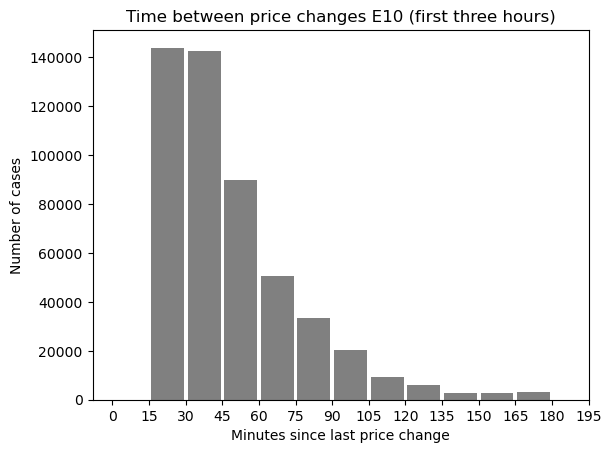

In [47]:
# Time interval between price changes, E10
mask = changes_e10['minutes_since_change'] <= 180

plt.figure()
plt.hist(
    changes_e10.loc[mask, 'minutes_since_change'],
    bins = np.arange(0, 195, 15),
    density=False,
    color='gray',
    rwidth=0.9 
)
plt.title("Time between price changes E10 (first three hours)")
plt.xlabel("Minutes since last price change")
plt.ylabel("Number of cases")
xticks = range(0, 201, 15)
plt.xticks(xticks)
plt.savefig(
    Setup.GRAPHS_DIR / "01_Descriptive_Statistics" / "02_07_price_changes_time_E10.png",
    dpi=200
)
plt.show()

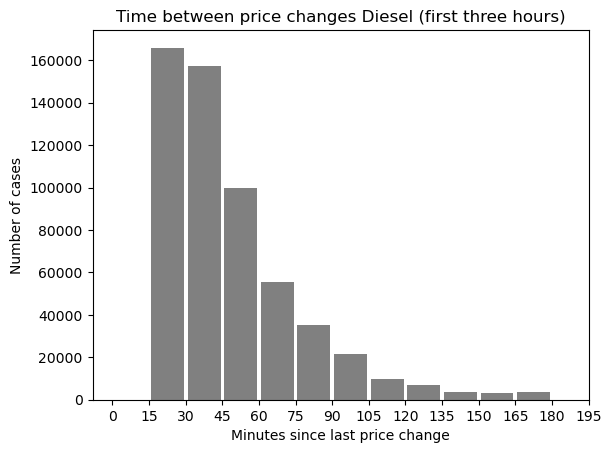

In [48]:
# Time interval between price changes, Diesel
mask = changes_diesel['minutes_since_change'] <= 180

plt.figure()
plt.hist(
    changes_diesel.loc[mask, 'minutes_since_change'],
    bins = np.arange(0, 195, 15),
    density=False,
    color='gray',
    rwidth=0.9 
)
plt.title("Time between price changes Diesel (first three hours)")
plt.xlabel("Minutes since last price change")
plt.ylabel("Number of cases")
xticks = range(0, 201, 15)
plt.xticks(xticks)
plt.savefig(
    Setup.GRAPHS_DIR / "01_Descriptive_Statistics" / "02_08_price_changes_time_Diesel.png",
    dpi=200
)
plt.show()

# 3. Changes to the Prices

In [41]:
df = df.sort_values(['station_uuid', 'date'])

# Create change indicator columns: 1 if the price changes compared to the previous observation at the same station
df['change_diesel'] = df.groupby('station_uuid')['diesel'].diff().ne(0).astype(int)
df['change_e5']     = df.groupby('station_uuid')['e5'].diff().ne(0).astype(int)
df['change_e10']    = df.groupby('station_uuid')['e10'].diff().ne(0).astype(int)

# Extract only the date part (without time)
df['day'] = df['date'].dt.date

# Sum the number of changes per station and day
daily_changes = df.groupby(['station_uuid', 'day'])[['change_diesel', 'change_e5', 'change_e10']].sum().reset_index()

# Print min, average, and max number of changes per fuel type
for fuel in ['change_diesel', 'change_e5', 'change_e10']:
    print(f"--- {fuel.upper()} ---")
    print('min:', daily_changes[fuel].min())
    print('avg:', daily_changes[fuel].mean())
    print('max:', daily_changes[fuel].max())

# Summary statistics (min, mean, max) for all fuel types
summary = daily_changes[['change_diesel', 'change_e5', 'change_e10']].agg(['min', 'mean', 'max'])
print(summary)

--- CHANGE_DIESEL ---
min: 0
avg: 40.02148600407033
max: 96
--- CHANGE_E5 ---
min: 0
avg: 41.69419143896173
max: 96
--- CHANGE_E10 ---
min: 0
avg: 45.62492910285924
max: 96
      change_diesel  change_e5  change_e10
min        0.000000   0.000000    0.000000
mean      40.021486  41.694191   45.624929
max       96.000000  96.000000   96.000000


In [42]:
# Sort data by station and timestamp
df = df.sort_values(['station_uuid', 'date'])

# Compute price differences compared to previous observation at the same station
df['diff_diesel'] = df.groupby('station_uuid')['diesel'].diff()
df['diff_e5']     = df.groupby('station_uuid')['e5'].diff()
df['diff_e10']    = df.groupby('station_uuid')['e10'].diff()

# Dictionary to store results
results = {}

# Loop over fuel types and calculate statistics for price increases and decreases
for fuel, diff_col in [('diesel', 'diff_diesel'), ('e5', 'diff_e5'), ('e10', 'diff_e10')]:
    decrease = df[df[diff_col] < 0][diff_col]
    increase = df[df[diff_col] > 0][diff_col]
    
    results[fuel] = {
        'decrease_min': decrease.min(),
        'decrease_max': decrease.max(),
        'decrease_avg': decrease.mean(),
        'increase_min': increase.min(),
        'increase_max': increase.max(),
        'increase_avg': increase.mean()
    }

# Display results nicely as DataFrame
df_results = pd.DataFrame(results).T
print(df_results)


        decrease_min  decrease_max  decrease_avg  increase_min  increase_max  \
diesel         -0.26        -0.001     -0.022596         0.001          0.25   
e5             -0.21        -0.001     -0.022540         0.001          0.25   
e10            -0.21        -0.001     -0.022523         0.005          0.25   

        increase_avg  
diesel      0.041949  
e5          0.041303  
e10         0.040874  


In [43]:
# Select only the desired time period (e.g., April 7–13)
start = pd.Timestamp('2025-04-07')
end = pd.Timestamp('2025-04-13 23:59:59')
subset = df[(df['date'] >= start) & (df['date'] <= end)]

# Min, Max, and Average for each fuel type
summary = subset[['diesel', 'e5', 'e10']].agg(['min', 'max', 'mean'])
print(summary)


        diesel       e5       e10
min   1.419000  1.58900  1.529000
max   2.139000  2.29900  2.239000
mean  1.577335  1.73503  1.679531


In [44]:
# All gas station coordinates
coords = df[['latitude', 'longitude']].drop_duplicates().to_numpy()
coords_rad = np.deg2rad(coords)  # BallTree requires radians

# Build BallTree
tree = BallTree(coords_rad, metric='haversine')

# Radii in kilometers (Earth radius ~6371 km)
radii_km = [3, 5, 10]
radii_rad = [r / 6371 for r in radii_km]  # Convert km to radians

neighbor_counts = {}

for r_km, r_rad in zip(radii_km, radii_rad):
    # For each coordinate: number of neighbors within the radius (including itself!)
    ind = tree.query_radius(coords_rad, r=r_rad)
    n_neighbors = np.array([len(x) - 1 for x in ind])  # subtract 1 because a station matches itself
    neighbor_counts[r_km] = {
        'min': n_neighbors.min(),
        'avg': n_neighbors.mean(),
        'max': n_neighbors.max()
    }

# Output
for r in radii_km:
    print(f"{r} km --- min: {neighbor_counts[r]['min']}, avg: {neighbor_counts[r]['avg']:.2f}, max: {neighbor_counts[r]['max']}")


3 km --- min: 0, avg: 3.02, max: 15
5 km --- min: 0, avg: 5.35, max: 22
10 km --- min: 1, avg: 11.97, max: 38


# 4. Neighbours based on Distance Definition

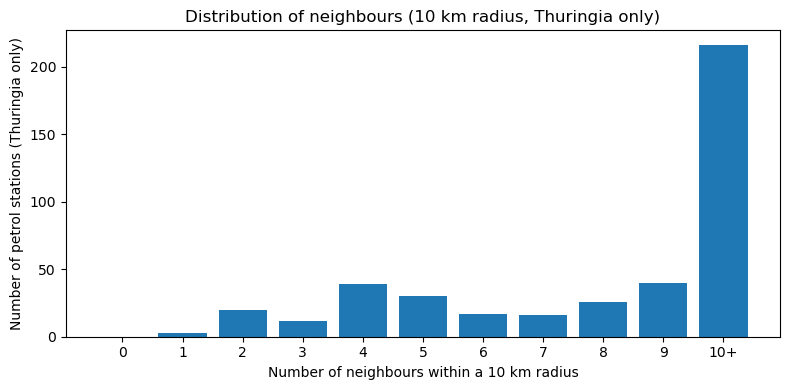

In [52]:
id_col = "station_uuid"
region_col = "in_thuringia"

# Meta table: each station exactly once with coordinates + Thuringia flag
meta = (
    df[[id_col, "latitude", "longitude", region_col]]
    .drop_duplicates(id_col)
    .reset_index(drop=True)
)

coords = meta[["latitude", "longitude"]].to_numpy()
coords_rad = np.deg2rad(coords)

# Neighbours within a 10 km radius for ALL stations
tree = BallTree(coords_rad, metric="haversine")
r_km = 10
r_rad = r_km / 6371

ind_10 = tree.query_radius(coords_rad, r=r_rad)
n_neighbors_10 = np.array([len(x) - 1 for x in ind_10])

# Thuringia mask (same order as coords_rad)
th_mask = meta[region_col].to_numpy(dtype=bool)
n_neighbors_th = n_neighbors_10[th_mask]

counts = []
labels = []

for k in range(0, 10):
    counts.append((n_neighbors_th == k).sum())
    labels.append(str(k))

counts.append((n_neighbors_th >= 10).sum())
labels.append("10+")

plt.figure(figsize=(8, 4))
plt.bar(labels, counts)
plt.xlabel("Number of neighbours within a 10 km radius")
plt.ylabel("Number of petrol stations (Thuringia only)")
plt.title("Distribution of neighbours (10 km radius, Thuringia only)")
plt.tight_layout()
plt.savefig(
    Setup.GRAPHS_DIR / "01_Descriptive_Statistics" / "04_01_abs_neighbour_distribution_dist.png",
    dpi=200
)
plt.show()

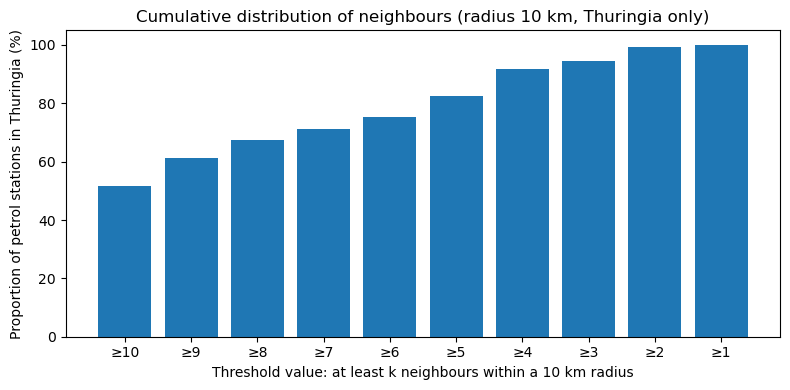

In [50]:
# Cumulative distribution ‘from above’: at least 10, at least 9, ..., at least 0 neighbours

k_values_desc = list(range(10, 0, -1))  # 10, 9, 8, ..., 0

cum_counts_desc = [ (n_neighbors_th >= k).sum() for k in k_values_desc ]
cum_perc_desc   = [ c / N_th * 100 for c in cum_counts_desc ]

labels_desc = [f"≥{k}" for k in k_values_desc]

plt.figure(figsize=(8, 4))
plt.bar(labels_desc, cum_perc_desc)
plt.xlabel("Threshold value: at least k neighbours within a 10 km radius")
plt.ylabel("Proportion of petrol stations in Thuringia (%)")
plt.title("Cumulative distribution of neighbours (radius 10 km, Thuringia only)")
plt.tight_layout()
plt.savefig(
    Setup.GRAPHS_DIR / "01_Descriptive_Statistics" / "04_02_cum_neighbour_distribution_dist.png",
    dpi=200
)
plt.show()

# 5. Neigbours based on Travel Times

In [16]:
tt = pd.read_csv("/home/qusta100/STGNN/01_Data/02_Processed_Data/01_OSMR/stations_travel_times.csv.gz")
tt = tt[tt["travel_time_min"] < 10]

cols = ["station_uuid", "in_thuringia"]
stations = (
    df[cols]
    .dropna(subset=cols)
    .drop_duplicates(subset=["station_uuid"])
    .reset_index(drop=True)
)

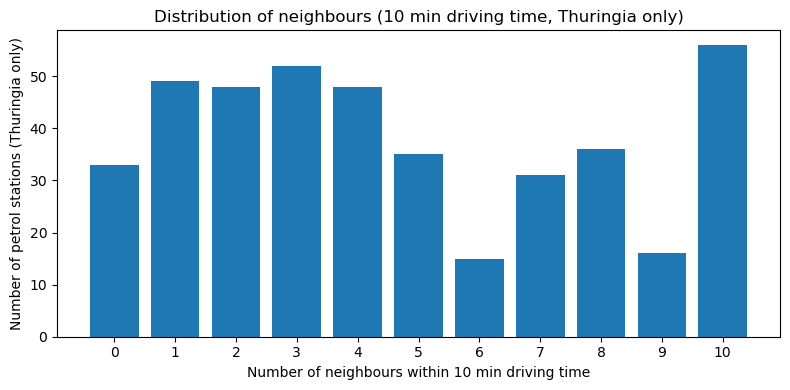

In [30]:
# Filter Thuringia
thu_src = stations.loc[stations["in_thuringia"] == True, "station_uuid"]
tt_thu = tt[tt["src_uuid"].isin(thu_src)].copy()

# Count Neighbours
neigh_counts = tt_thu.groupby("src_uuid")["dst_uuid"].size()
neigh_counts = neigh_counts.reindex(thu_src, fill_value=0)

# Discrete classes
neigh_capped = neigh_counts.clip(upper=10).astype(int)
labels = list(range(0, 11))                  # 0..10
counts = [(neigh_capped == k).sum() for k in labels]

plt.figure(figsize=(8, 4))
plt.bar(labels, counts)
plt.xlabel("Number of neighbours within 10 min driving time")
plt.ylabel("Number of petrol stations (Thuringia only)")
plt.title("Distribution of neighbours (10 min driving time, Thuringia only)")
plt.xticks(labels)
plt.tight_layout()
plt.savefig(
    Setup.GRAPHS_DIR / "01_Descriptive_Statistics" / "05_01_abs_neighbour_distribution_time.png",
    dpi=200
)
plt.show()

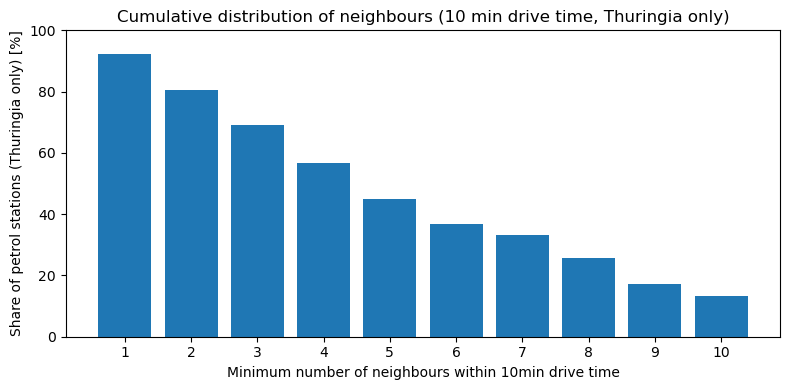

In [28]:
labels = list(range(1, 11))  # mindestens 1 bis mindestens 10
n_total = len(neigh_capped)
cum_perc = [(neigh_capped >= k).sum() / n_total * 100 for k in labels]

plt.figure(figsize=(8, 4))
plt.bar(labels, cum_perc)
plt.xlabel("Minimum number of neighbours within 10min drive time")
plt.ylabel("Share of petrol stations (Thuringia only) [%]")
plt.title("Cumulative distribution of neighbours (10 min drive time, Thuringia only)")
plt.xticks(labels)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(
    Setup.GRAPHS_DIR / "01_Descriptive_Statistics" / "05_02_cum_neighbour_distribution_time.png",
    dpi=200
)
plt.show()